# load data

In [78]:
# Import necessary libraries
import pandas as pd
import os
import seaborn as sns
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import numpy as np
import warnings

# Ignore warning messages for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style and default figure size
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = '../dataset/02_after_clean/'
print("Loading data...")

df_products = pd.read_parquet(DATA_PATH + 'products.parquet')
df_customers = pd.read_parquet(DATA_PATH + 'customers.parquet')
df_promotions = pd.read_parquet(DATA_PATH + 'promotions.parquet')
df_geography = pd.read_parquet(DATA_PATH + 'geography.parquet')

df_orders = pd.read_parquet(DATA_PATH + 'orders.parquet')
df_order_items = pd.read_parquet(DATA_PATH + 'order_items.parquet')
df_shipments = pd.read_parquet(DATA_PATH + 'shipments.parquet')
df_returns = pd.read_parquet(DATA_PATH + 'returns.parquet')
df_reviews = pd.read_parquet(DATA_PATH + 'reviews.parquet')

df_sales = pd.read_parquet(DATA_PATH + 'sales.parquet')

df_inventory = pd.read_parquet(DATA_PATH + 'inventory.parquet')
df_web_traffic = pd.read_parquet(DATA_PATH + 'web_traffic.parquet')

print("Load data successfully")

Loading data...
Load data successfully


# kiểm tra tồn kho và trả hàng

In [79]:
df_check = df_order_items.copy()
df_check = df_check.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')
df_check = df_check[(df_check['order_date'] >= '2012-07-01') & (df_check['order_date'] <= '2012-07-31')]
df_check = df_check[df_check['product_id'] == 1202]
print(df_check)

Empty DataFrame
Columns: [order_id, product_id, quantity, unit_price, discount_amount, promo_id, promo_id_2, order_date]
Index: []


# kiểm tra web traffic

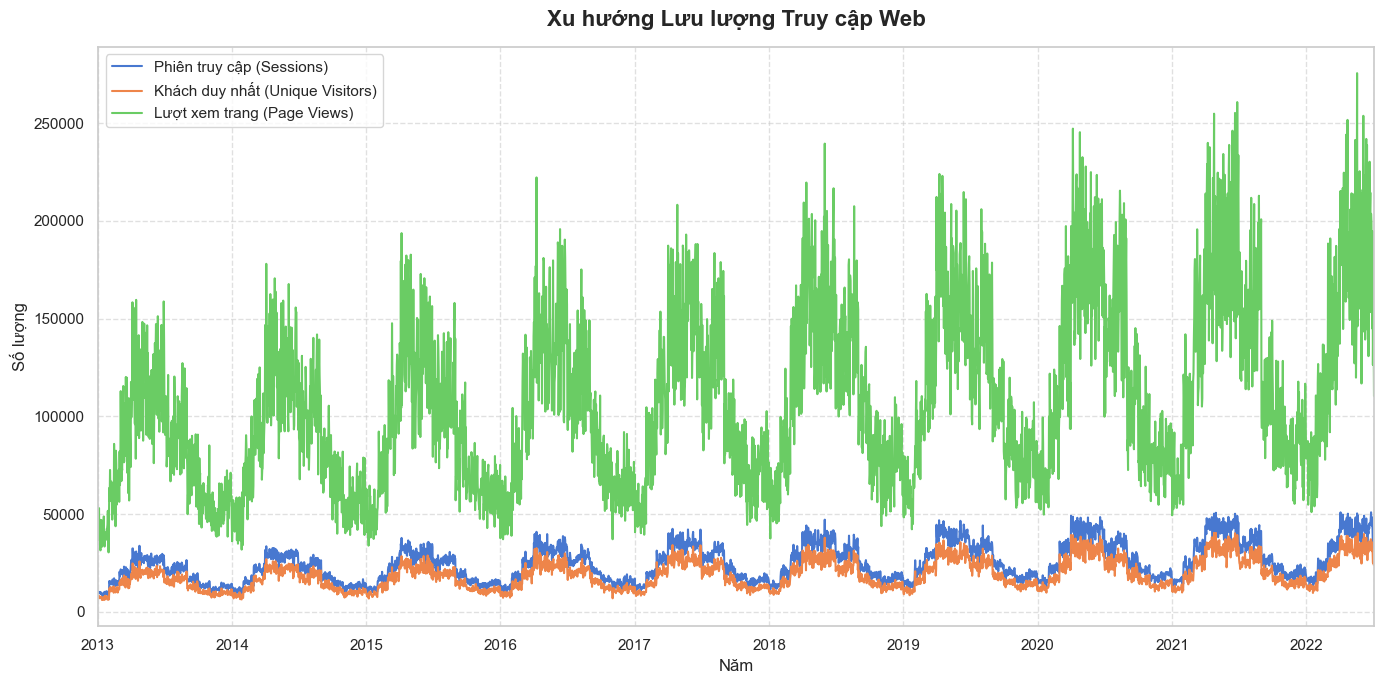

In [80]:
start_date = '2012-07-04'
end_date = '2022-07-04'
df_web_traffic_check = df_web_traffic[(df_web_traffic['date'] >= start_date) & (df_web_traffic['date'] <= end_date)]

df_web_traffic_check = df_web_traffic_check.set_index('date')
columns_to_plot = ['sessions', 'unique_visitors', 'page_views']
ax = df_web_traffic_check[columns_to_plot].plot(figsize=(14, 7), linewidth=1.5)

plt.title('Xu hướng Lưu lượng Truy cập Web', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.legend(['Phiên truy cập (Sessions)', 'Khách duy nhất (Unique Visitors)', 'Lượt xem trang (Page Views)'])

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

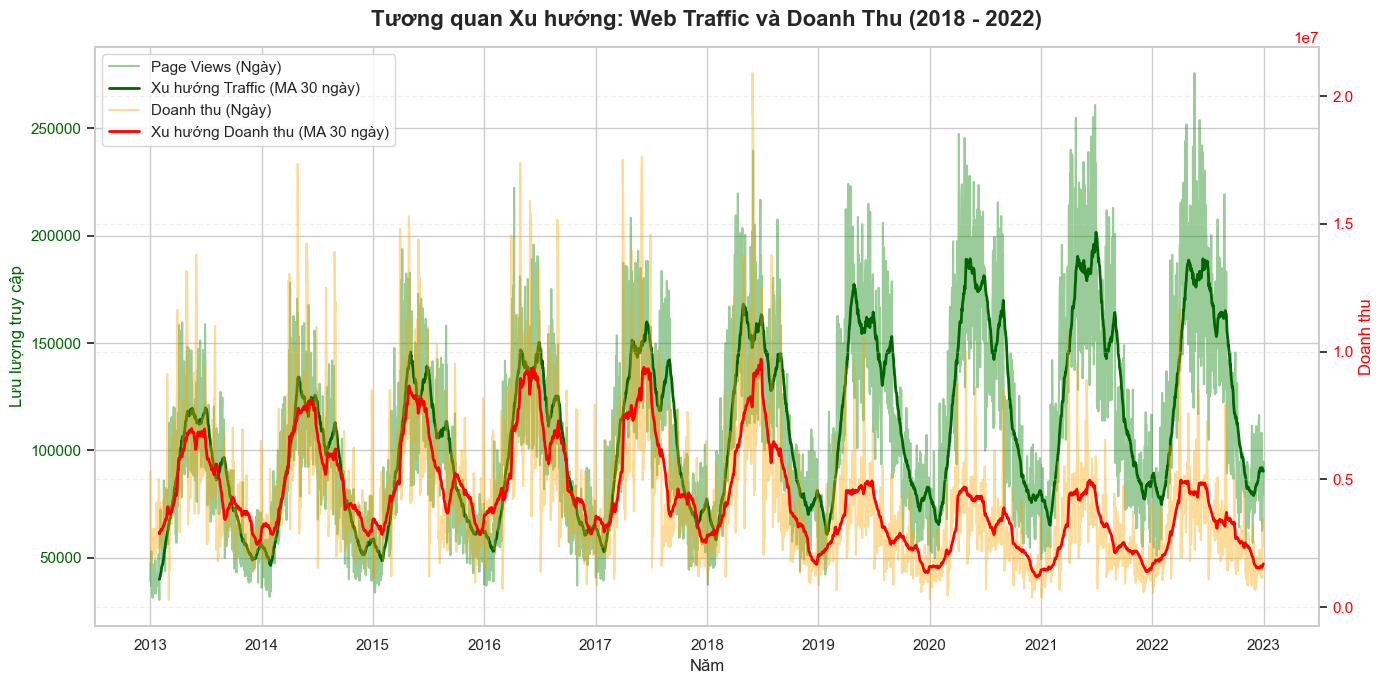

In [81]:

# --- 1. LỌC DỮ LIỆU CHUẨN ---
start_date = pd.to_datetime('2013-01-01')
end_date = pd.to_datetime('2022-12-31')

# Lọc và dùng .copy() để tránh cảnh báo của Pandas
df_web_traffic_check = df_web_traffic[(df_web_traffic['date'] >= start_date) & (df_web_traffic['date'] <= end_date)].copy()
df_sales_check = df_sales[(df_sales['Date'] >= start_date) & (df_sales['Date'] <= end_date)].copy()

# --- 2. ĐỒNG BỘ INDEX TRỤC THỜI GIAN (BƯỚC SỬA LỖI) ---
# Set index cho df_web_traffic_check
if 'date' in df_web_traffic_check.columns:
    df_web_traffic_check = df_web_traffic_check.set_index('date')

# Set index cho df_sales_check
if 'Date' in df_sales_check.columns:
    df_sales_check = df_sales_check.set_index('Date')

# --- 3. VẼ BIỂU ĐỒ ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- TRỤC Y THỨ NHẤT (TRAFFIC) ---
ax1.plot(df_web_traffic_check.index, df_web_traffic_check['page_views'], color='green', alpha=0.4, label='Page Views (Ngày)')
ax1.plot(df_web_traffic_check.index, df_web_traffic_check['page_views'].rolling(window=30).mean(), 
         color='darkgreen', linewidth=2, label='Xu hướng Traffic (MA 30 ngày)')

ax1.set_xlabel('Năm', fontsize=12)
ax1.set_ylabel('Lưu lượng truy cập', color='darkgreen', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkgreen')

# --- TRỤC Y THỨ HAI (REVENUE) ---
ax2 = ax1.twinx()
ax2.plot(df_sales_check.index, df_sales_check['Revenue'], color='orange', alpha=0.4, label='Doanh thu (Ngày)')
ax2.plot(df_sales_check.index, df_sales_check['Revenue'].rolling(window=30).mean(), 
         color='red', linewidth=2, label='Xu hướng Doanh thu (MA 30 ngày)')

ax2.set_ylabel('Doanh thu', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# --- TRÌNH BÀY ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Tương quan Xu hướng: Web Traffic và Doanh Thu (2018 - 2022)', fontsize=16, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [82]:
df_check = df_web_traffic.copy().sort_values(by='date')
df_check = df_check.merge(df_sales, left_on='date', right_on='Date', how='left')
df_check = df_check.sort_values(by='date')

total_order = df_orders.groupby('order_date')['order_id'].count()
df_check['total_order'] = df_check['date'].map(total_order).fillna(0)
df_check['conversion_rate'] = df_check['total_order'] / df_check['sessions']
df_check['AOV'] = df_check['Revenue'] / df_check['total_order']

display(df_check[['date', 'conversion_rate', 'AOV', 'sessions', 'Revenue', 'total_order']].head(10))

,date,conversion_rate,AOV,sessions,Revenue,total_order
0,2013-01-01,0.029508,18418.565937,9760,5304546.99,288
1,2013-01-02,0.004495,34190.222128,10456,1606940.44,47
2,2013-01-03,0.008039,28168.889012,10076,2281680.01,81
3,2013-01-04,0.008322,28637.294699,9973,2376895.46,83
4,2013-01-05,0.007630,32172.599615,10223,2509462.77,78
5,2013-01-06,0.009743,27993.080860,9545,2603356.52,93
6,2013-01-07,0.011075,26974.339735,10203,3048100.39,113
7,2013-01-08,0.009518,27218.893556,9456,2449700.42,90
8,2013-01-09,0.008186,27329.542667,9162,2049715.70,75
9,2013-01-10,0.007990,35371.284304,9887,2794331.46,79


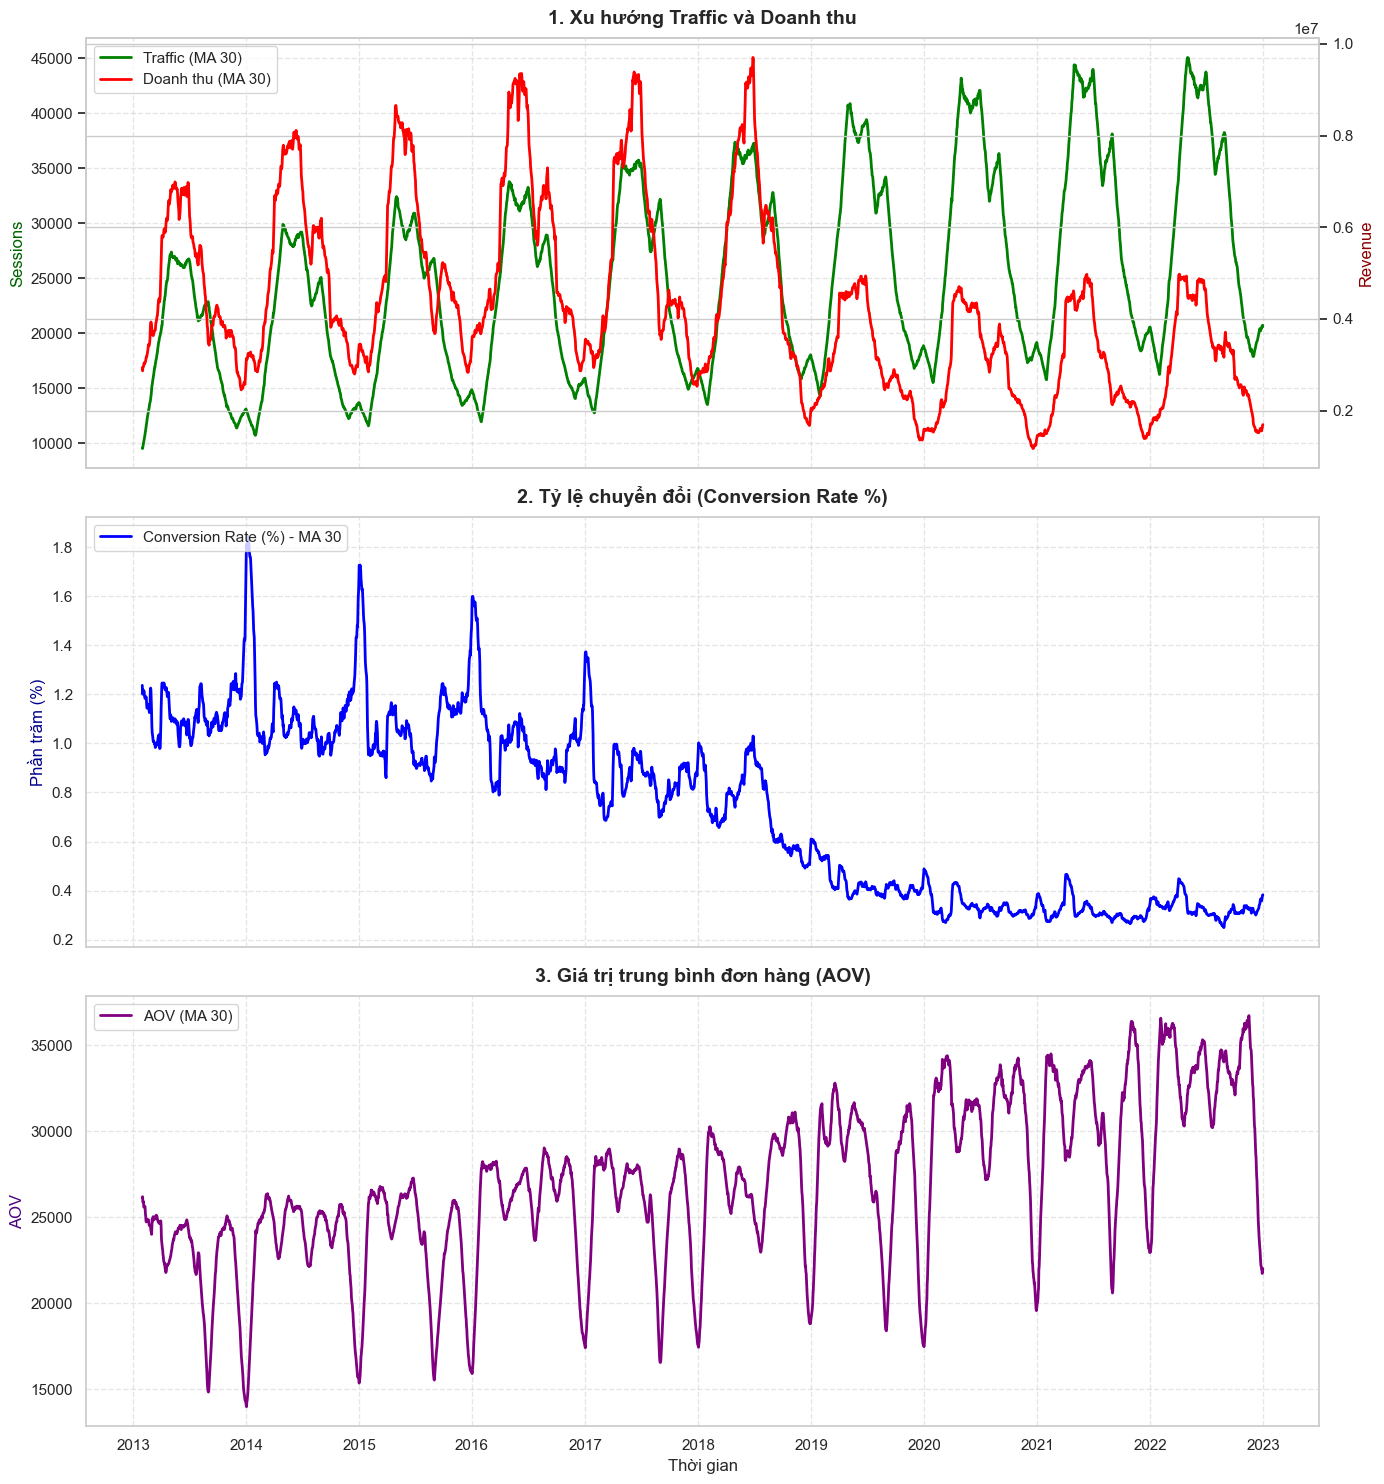

In [83]:
# 1. Đảm bảo 'date' là Index (trục thời gian)
if 'date' in df_check.columns:
    df_check = df_check.set_index('date')

# 2. Tạo khung vẽ gồm 3 hàng, 1 cột, dùng chung trục X (sharex=True)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Đặt biến khoảng thời gian lấy trung bình động (1 tháng = 30 ngày)
window = 30

# --- BIỂU ĐỒ 1: TRAFFIC VÀ DOANH THU (Để xem sự phân kỳ) ---
ax1_twin = ax1.twinx() # Tạo trục Y thứ 2 cho biểu đồ 1
ax1.plot(df_check.index, df_check['sessions'].rolling(window).mean(), color='green', linewidth=2, label='Traffic (MA 30)')
ax1_twin.plot(df_check.index, df_check['Revenue'].rolling(window).mean(), color='red', linewidth=2, label='Doanh thu (MA 30)')

ax1.set_title('1. Xu hướng Traffic và Doanh thu', fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel('Sessions', color='darkgreen', fontsize=12)
ax1_twin.set_ylabel('Revenue', color='darkred', fontsize=12)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 2: TỶ LỆ CHUYỂN ĐỔI (Conversion Rate) ---
# Tỷ lệ chuyển đổi thường là số thập phân nhỏ (0.01 = 1%), ta có thể nhân 100 để hiển thị % cho dễ nhìn
ax2.plot(df_check.index, (df_check['conversion_rate'] * 100).rolling(window).mean(), color='blue', linewidth=2, label='Conversion Rate (%) - MA 30')
ax2.set_title('2. Tỷ lệ chuyển đổi (Conversion Rate %)', fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel('Phần trăm (%)', color='darkblue', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 3: GIÁ TRỊ TRUNG BÌNH ĐƠN (AOV) ---
ax3.plot(df_check.index, df_check['AOV'].rolling(window).mean(), color='purple', linewidth=2, label='AOV (MA 30)')
ax3.set_title('3. Giá trị trung bình đơn hàng (AOV)', fontsize=14, fontweight='bold', pad=10)
ax3.set_ylabel('AOV', color='indigo', fontsize=12)
ax3.set_xlabel('Thời gian', fontsize=12)
ax3.legend(loc='upper left')
ax3.grid(True, linestyle='--', alpha=0.5)

# --- TRÌNH BÀY TỔNG THỂ ---
plt.tight_layout()
plt.show()

# kiểm tra promotion

In [84]:
df_check = df_order_items.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')


# 1. Tạo một "từ điển" ánh xạ từ df_promotions (Khóa: promo_id, Giá trị: start_day)
promo_mapping_start = df_promotions.set_index('promo_id')['start_date']
promo_mapping_end = df_promotions.set_index('promo_id')['end_date']

df_check['start_date_pmot_1'] = df_check['promo_id'].map(promo_mapping_start)
df_check['end_date_pmot_1'] = df_check['promo_id'].map(promo_mapping_end)

df_check['start_date_pmot_2'] = df_check['promo_id_2'].map(promo_mapping_start)
df_check['end_date_pmot_2'] = df_check['promo_id_2'].map(promo_mapping_end)

df_check.info()
display(df_check.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   order_id           714669 non-null  string        
 1   product_id         714669 non-null  string        
 2   quantity           714669 non-null  int64         
 3   unit_price         714669 non-null  float64       
 4   discount_amount    714669 non-null  float64       
 5   promo_id           714669 non-null  string        
 6   promo_id_2         714669 non-null  string        
 7   order_date         714669 non-null  datetime64[ns]
 8   start_date_pmot_1  276316 non-null  datetime64[ns]
 9   end_date_pmot_1    276316 non-null  datetime64[ns]
 10  start_date_pmot_2  206 non-null     datetime64[ns]
 11  end_date_pmot_2    206 non-null     datetime64[ns]
dtypes: datetime64[ns](5), float64(2), int64(1), string(4)
memory usage: 65.4 MB


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,start_date_pmot_1,end_date_pmot_1,start_date_pmot_2,end_date_pmot_2
283618,323859,792,1,740.82,74.08,PROMO-0013,None,2015-09-15,2015-08-30,2015-10-01,NaT,NaT
540650,624623,206,2,10504.96,0.00,None,None,2018-08-23,NaT,NaT,NaT,NaT
204659,233165,2235,7,669.77,937.68,PROMO-0010,None,2014-11-22,2014-11-19,2015-01-02,NaT,NaT
642198,746080,633,8,6914.73,0.00,None,None,2021-02-14,NaT,NaT,NaT,NaT
711861,831074,826,8,10004.51,16007.22,PROMO-0050,None,2022-11-29,2022-11-18,2022-12-31,NaT,NaT


In [85]:
# 1. Xác định các trường hợp KHÔNG CÓ mã khuyến mãi (None, NaN, rỗng)
no_promo_1 = df_check['promo_id'].isna() | (df_check['promo_id'] == 'None') | (df_check['promo_id'] == '')
no_promo_2 = df_check['promo_id_2'].isna() | (df_check['promo_id_2'] == 'None') | (df_check['promo_id_2'] == '')

# 2. Xác định các trường hợp ngày tháng HỢP LỆ (nằm trong khoảng)
valid_date_1 = (df_check['order_date'] >= df_check['start_date_pmot_1']) & (df_check['order_date'] <= df_check['end_date_pmot_1'])
valid_date_2 = (df_check['order_date'] >= df_check['start_date_pmot_2']) & (df_check['order_date'] <= df_check['end_date_pmot_2'])

# 3. Kết hợp lại: Không có mã (mặc định True) HOẶC Ngày hợp lệ
df_check['is_valid_promo_1'] = no_promo_1 | valid_date_1
df_check['is_valid_promo_2'] = no_promo_2 | valid_date_2

print(df_check['is_valid_promo_1'].value_counts())
print(df_check['is_valid_promo_2'].value_counts())

# Xem thử kết quả
cols_to_view = ['order_date', 'promo_id', 'start_date_pmot_1', 'is_valid_promo_1']
display(df_check[cols_to_view].sample(10))

is_valid_promo_1
True    714669
Name: count, dtype: Int64
is_valid_promo_2
True    714669
Name: count, dtype: Int64


,order_date,promo_id,start_date_pmot_1,is_valid_promo_1
258159,2015-06-14,None,NaT,True
676097,2021-12-28,PROMO-0044,2021-11-18,True
294764,2015-11-05,None,NaT,True
502782,2018-04-23,None,NaT,True
607869,2020-03-19,None,NaT,True
363845,2016-07-26,None,NaT,True
401398,2017-01-25,None,NaT,True
491116,2018-03-04,None,NaT,True
628725,2020-08-18,None,NaT,True
480331,2017-12-23,PROMO-0024,2017-11-18,True


In [86]:
df_promotions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   promo_id             50 non-null     string        
 1   promo_name           50 non-null     string        
 2   promo_type           50 non-null     category      
 3   discount_value       50 non-null     float64       
 4   start_date           50 non-null     datetime64[ns]
 5   end_date             50 non-null     datetime64[ns]
 6   applicable_category  50 non-null     category      
 7   promo_channel        50 non-null     category      
 8   stackable_flag       50 non-null     bool          
 9   min_order_value      50 non-null     int64         
dtypes: bool(1), category(3), datetime64[ns](2), float64(1), int64(1), string(2)
memory usage: 3.1 KB


In [87]:
# Giả sử DataFrame của bạn đang tên là df_promotions (bạn hãy đổi lại cho đúng với code thực tế nhé)

# 1. Tạo cột mới tính số ngày giữa start_date và end_date
# Dùng .dt.days để chuyển đổi kết quả trừ thời gian (timedelta) thành một con số nguyên (int)
df_promotions['duration_days'] = (df_promotions['end_date'] - df_promotions['start_date']).dt.days

# 2. Xuất ra (các) dòng có end_date mới nhất (lớn nhất)
# Dùng == .max() sẽ giúp bạn lấy ra TẤT CẢ các dòng nếu lỡ có nhiều khuyến mãi cùng kết thúc vào ngày hôm đó
newest_end_promo = df_promotions[df_promotions['end_date'] == df_promotions['end_date'].max()]
print("--- Khuyến mãi có ngày kết thúc mới nhất ---")
display(newest_end_promo)

# 3. Xuất ra (các) dòng có start_date cũ nhất (nhỏ nhất)
oldest_start_promo = df_promotions[df_promotions['start_date'] == df_promotions['start_date'].min()]
print("\n--- Khuyến mãi có ngày bắt đầu cũ nhất ---")
display(oldest_start_promo)

--- Khuyến mãi có ngày kết thúc mới nhất ---


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value,duration_days
49,PROMO-0050,Year-End Sale 2022,percentage,20.0,2022-11-18,2022-12-31,All,all_channels,False,50000,43



--- Khuyến mãi có ngày bắt đầu cũ nhất ---


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value,duration_days
5,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,False,0,29


In [88]:
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])
df_promotions['duration_days'] = (df_promotions['end_date'] - df_promotions['start_date']).dt.days

# Lệnh dt.month sẽ chỉ lấy số tháng (từ 1 đến 12), bỏ qua năm
df_promotions['month'] = df_promotions['start_date'].dt.month
df_promotions['year'] = df_promotions['start_date'].dt.year

df_promotions['start_day_month'] = df_promotions['start_date'].dt.strftime('%d-%m')
df_promotions['end_day_month'] = df_promotions['end_date'].dt.strftime('%d-%m')

df_promotions = df_promotions.sort_values(by=['start_day_month', 'start_date'])
df_promotions.to_parquet('pmot_test.parquet')

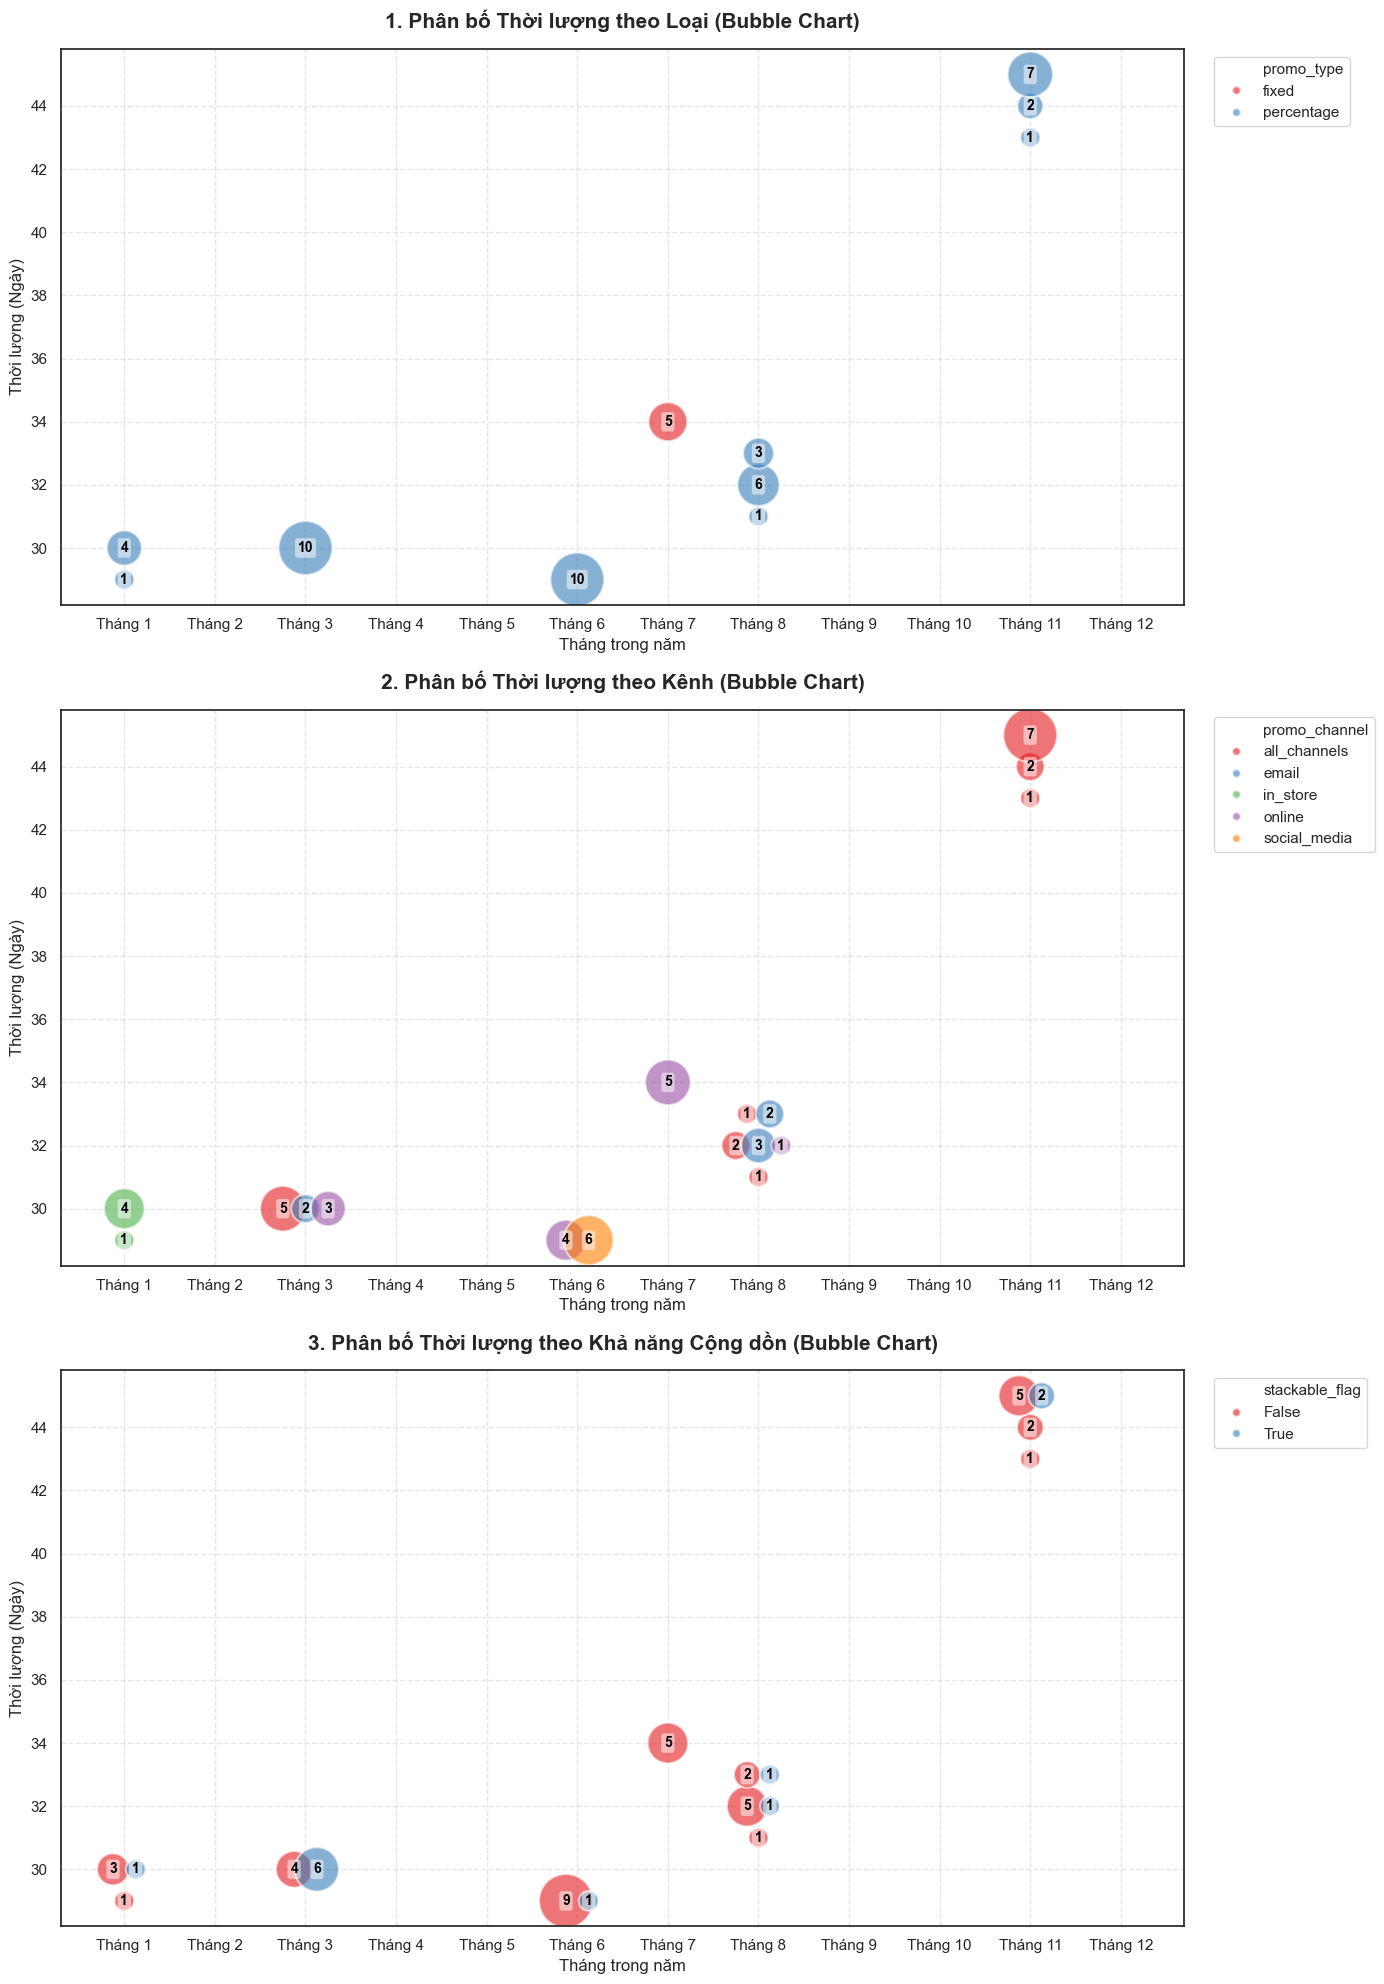

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def draw_bubble_chart_optimized(ax, data, hue_column, title):
    # 1. Nhóm dữ liệu (Bỏ các nhóm count = 0)
    df_agg = data.groupby(['month', 'duration_days', hue_column]).size().reset_index(name='promo_count')
    df_agg = df_agg[df_agg['promo_count'] > 0].copy()
    
    # 2. XỬ LÝ CHỐNG ĐỀ (JITTERING): Dịch chuyển nhẹ theo trục X nếu trùng tọa độ
    # Đếm xem tại một điểm (month, duration_days) có bao nhiêu bong bóng chồng lên nhau
    df_agg['group_size'] = df_agg.groupby(['month', 'duration_days'])['month'].transform('size')
    # Đánh số thứ tự cho các bong bóng trùng nhau
    df_agg['rank'] = df_agg.groupby(['month', 'duration_days']).cumcount()
    
    # Tính toán tọa độ X mới (Lệch một chút so với tháng gốc)
    # Khoảng cách lệch (spacing) có thể tinh chỉnh (hiện tại là 0.25)
    spacing = 0.25 
    df_agg['month_jittered'] = df_agg['month'] + (df_agg['rank'] - (df_agg['group_size'] - 1) / 2) * spacing

    # 3. Vẽ bong bóng (Sử dụng X mới là month_jittered)
    sns.scatterplot(
        data=df_agg,
        x='month_jittered', 
        y='duration_days',
        hue=hue_column,
        size='promo_count',
        sizes=(200, 1500), # Giữ nguyên size bong bóng của bạn
        alpha=0.6,
        edgecolor='white',
        linewidth=1.5,
        ax=ax,
        palette='Set1'
    )
    
    # 4. In số lượng cho TỪNG BONG BÓNG (đã được tách rời)
    for _, row in df_agg.iterrows():
        ax.text(
            row['month_jittered'], 
            row['duration_days'],
            str(int(row['promo_count'])),
            color='black',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2')
        )

    # 5. Trình bày Layout
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('Thời lượng (Ngày)', fontsize=12)
    ax.set_xlabel('Tháng trong năm', fontsize=12)
    
    # Ép trục X hiển thị chính xác các tháng (1 -> 12) dù bong bóng có bị dịch lệch
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([f'Tháng {i}' for i in range(1, 13)])
    # Mở rộng trục X một chút để các bong bóng bị đẩy ra biên không bị cắt viền
    ax.set_xlim(0.3, 12.7) 

    # Dọn dẹp Legend (Chú thích)
    handles, labels = ax.get_legend_handles_labels()
    # Tìm index của 'promo_count' để cắt bỏ phần hướng dẫn size, chỉ giữ lại chú thích màu sắc
    cut_idx = labels.index('promo_count') if 'promo_count' in labels else len(labels)
    ax.legend(handles[:cut_idx], labels[:cut_idx], bbox_to_anchor=(1.02, 1), loc='upper left')
    
    ax.grid(True, linestyle='--', alpha=0.5)
    
sns.set_theme(style="white")
fig, axes = plt.subplots(3, 1, figsize=(14, 20))

draw_bubble_chart_optimized(axes[0], df_promotions, 'promo_type', '1. Phân bố Thời lượng theo Loại (Bubble Chart)')
draw_bubble_chart_optimized(axes[1], df_promotions, 'promo_channel', '2. Phân bố Thời lượng theo Kênh (Bubble Chart)')
draw_bubble_chart_optimized(axes[2], df_promotions, 'stackable_flag', '3. Phân bố Thời lượng theo Khả năng Cộng dồn (Bubble Chart)')

plt.tight_layout()
plt.show()

# kiểm tra inventory

In [90]:
df_inventory.describe(include='all')
df_check = df_inventory.sort_values(by='snapshot_date').reset_index()
df_check['recei_sold'] = df_check['units_received'] - df_check['units_sold']
df_check = df_check[['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'overstock_flag', 'sell_through_rate']]

df_check = df_check[df_check['product_id'].isin(['1942', '1202'])].reset_index()
df_check.to_parquet('inventory.parquet', engine='pyarrow')


# kiểm tra return, review với order

In [91]:
df_check = df_orders[['order_id', 'order_date', 'order_status', 'payment_method']].copy()
df_check = df_check.merge(df_shipments, on='order_id', how='left')

df_check['is_returned'] = df_check['order_id'].isin(df_returns['order_id']).astype(bool)
df_check['is_reviewed'] = df_check['order_id'].isin(df_reviews['order_id']).astype(bool)

df_check.info()
print(df_check['order_status'].value_counts())
df_check.to_parquet('check_ret_rev.parquet', engine='pyarrow')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  string        
 1   order_date      646945 non-null  datetime64[ns]
 2   order_status    646945 non-null  category      
 3   payment_method  646945 non-null  category      
 4   ship_date       566067 non-null  datetime64[ns]
 5   delivery_date   566067 non-null  datetime64[ns]
 6   shipping_fee    566067 non-null  float64       
 7   is_returned     646945 non-null  bool          
 8   is_reviewed     646945 non-null  bool          
dtypes: bool(2), category(2), datetime64[ns](3), float64(1), string(1)
memory usage: 27.1 MB
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


In [92]:
statuses = df_check['order_status'].unique()

for status in statuses:
    df_temp = df_check[df_check['order_status'] == status]
    total_rows = len(df_temp)
    
    count_review = len(df_temp[df_temp['is_reviewed'] == 1])
    count_return = len(df_temp[df_temp['is_returned'] == 1])
    count_ship = df_temp['ship_date'].notna().sum()
    count_deli = df_temp['delivery_date'].notna().sum()
    
    print(f"--- Status: {status.upper()} ---")
    print(f"Tổng số dòng: {total_rows}")
    print(f"Số dòng đã review: {count_review}")
    print(f"Số dòng đã return: {count_return}")
    print(f"Số dòng có ship_date: {count_ship}")
    print(f"Số dòng có delivery_date: {count_deli}")
    print("-" * 30)

--- Status: DELIVERED ---
Tổng số dòng: 516716
Số dòng đã review: 111369
Số dòng đã return: 0
Số dòng có ship_date: 516192
Số dòng có delivery_date: 516192
------------------------------
--- Status: RETURNED ---
Tổng số dòng: 36142
Số dòng đã review: 0
Số dòng đã return: 36062
Số dòng có ship_date: 36113
Số dòng có delivery_date: 36113
------------------------------
--- Status: SHIPPED ---
Tổng số dòng: 13773
Số dòng đã review: 0
Số dòng đã return: 0
Số dòng có ship_date: 13762
Số dòng có delivery_date: 13762
------------------------------
--- Status: CANCELLED ---
Tổng số dòng: 59462
Số dòng đã review: 0
Số dòng đã return: 0
Số dòng có ship_date: 0
Số dòng có delivery_date: 0
------------------------------
--- Status: PAID ---
Tổng số dòng: 13577
Số dòng đã review: 0
Số dòng đã return: 0
Số dòng có ship_date: 0
Số dòng có delivery_date: 0
------------------------------
--- Status: CREATED ---
Tổng số dòng: 7275
Số dòng đã review: 0
Số dòng đã return: 0
Số dòng có ship_date: 0
Số dòng 

In [93]:
df_temp = df_check[df_check['order_status'] == 'delivered']
df_temp = df_temp[df_temp['ship_date'].isna()]

print(len(df_temp[df_temp['is_reviewed'] == 1]))
df_temp.to_parquet('delivery.parquet')

0


# kiểm tra cogs và revenue

In [94]:
df_check = pd.merge(df_products[['product_id', 'cogs']], df_order_items[['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount']], on='product_id', how='left')
df_check = df_check.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')
df_check.info()
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 715483 entries, 0 to 715482
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   product_id       715483 non-null  string        
 1   cogs             715483 non-null  float64       
 2   order_id         714669 non-null  string        
 3   quantity         714669 non-null  float64       
 4   unit_price       714669 non-null  float64       
 5   discount_amount  714669 non-null  float64       
 6   order_date       714669 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), string(2)
memory usage: 38.2 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[ns]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
dt

In [95]:
df_check = df_check[df_check['order_date'].notna()]
df_check['total_cogs'] = (df_check['cogs'] * df_check['quantity'])

df_check['reve'] = df_check['quantity'] * df_check['unit_price'] - df_check['discount_amount']

cog_by_day = df_check.groupby('order_date')['total_cogs'].sum()
reve_by_day = df_check.groupby('order_date')['reve'].sum()

df_sales['compare_cogs'] = df_sales['Date'].map(cog_by_day)
df_sales['compare_reve'] = df_sales['Date'].map(reve_by_day)

df_sales['dif_cog'] = (df_sales['COGS'] - df_sales['compare_cogs']).astype(float)
df_sales['dif_reve'] = (df_sales['Revenue'] - df_sales['compare_reve']).astype(float)

mismatches_cog = df_sales[(df_sales['dif_cog'] != 0) | (df_sales['dif_cog'].isna())]
display(mismatches_cog.drop(columns=['Revenue', 'compare_reve', 'dif_reve']).sample(10))
print(df_sales['dif_cog'].max())
print(df_sales['dif_cog'].min())


mismatches_reve = df_sales[(df_sales['dif_reve'] != 0) | (df_sales['dif_reve'].isna())]
display(mismatches_reve.drop(columns=['COGS', 'compare_cogs', 'dif_cog']).sample(10))
print(df_sales['dif_reve'].max())
print(df_sales['dif_reve'].min())

,Date,COGS,compare_cogs,dif_cog
3257,2021-06-04,2097669.41,2.097669e+06,-0.000647
1283,2016-01-08,2202044.96,2.202045e+06,-0.003139
3728,2022-09-18,2098692.33,2.098692e+06,-0.000346
862,2014-11-13,2973473.14,2.973473e+06,0.003274
2213,2018-07-26,5212368.25,5.212368e+06,0.001952
2873,2020-05-16,3113947.78,3.113948e+06,0.004521
344,2013-06-13,5559998.61,5.559999e+06,0.003184
3461,2021-12-25,1156338.10,1.156338e+06,0.001686
1740,2017-04-09,4683867.18,4.683867e+06,0.004950
1240,2015-11-26,3392781.25,3.392781e+06,0.004242


0.00499926891643554
-0.004998689517378807


,Date,Revenue,compare_reve,dif_reve
1604,2016-11-24,1693041.10,1354432.89,3.386082e+05
3338,2021-08-24,1836322.27,1821672.27,1.465000e+04
1830,2017-07-08,2775904.89,2276242.04,4.996629e+05
143,2012-11-24,2283866.51,2283866.51,-4.656613e-10
3330,2021-08-16,2220064.67,2203164.67,1.690000e+04
1258,2015-12-14,3272227.86,2617782.27,6.544456e+05
3138,2021-02-05,1749418.05,1734202.02,1.521603e+04
1243,2015-11-29,5018236.03,4014588.84,1.003647e+06
1508,2016-08-20,5781551.94,5781551.94,9.313226e-10
277,2013-04-07,2924734.26,2573766.12,3.509681e+05


2623653.76
-1.862645149230957e-09


# temp

In [96]:
df_order_items.info()
for col in df_order_items.columns.tolist():
    print(df_order_items[col].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  string 
 1   product_id       714669 non-null  string 
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         714669 non-null  string 
 6   promo_id_2       714669 non-null  string 
dtypes: float64(2), int64(1), string(4)
memory usage: 38.2 MB
order_id
348761    5
594591    5
263667    4
319807    4
139629    4
         ..
834301    1
834303    1
834304    1
834305    1
834317    1
Name: count, Length: 646945, dtype: Int64
product_id
792     10160
791     10140
604      8115
2045     7925
487      7418
        ...  
1470        1
1487        1
1488        1
1602        1
210         1
Name: count, Length: 1598, dtype: Int64
quantity
1    896

In [97]:
df_products.info()
for col in df_products.columns.tolist():
    print(df_products[col].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   product_id    2412 non-null   string  
 1   product_name  2412 non-null   string  
 2   category      2412 non-null   category
 3   segment       2412 non-null   category
 4   size          2412 non-null   category
 5   color         2412 non-null   category
 6   price         2412 non-null   float64 
 7   cogs          2412 non-null   float64 
dtypes: category(4), float64(2), string(2)
memory usage: 86.0 KB
product_id
1264    1
536     1
537     1
538     1
539     1
       ..
551     1
552     1
553     1
554     1
555     1
Name: count, Length: 2412, dtype: Int64
product_name
VietMode RP-06       3
VietMode RP-01       3
VietMode RP-02       3
VietMode RP-07       3
VietMode RP-03       3
                    ..
HanoiStreet UC-48    1
HanoiStreet UC-49    1
HanoiStreet UC-50    1
SaigonFl

In [98]:
df_customers.info()
for col in df_customers.columns.tolist():
    print(df_customers[col].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          121930 non-null  string        
 1   zip                  121930 non-null  string        
 2   city                 121930 non-null  category      
 3   signup_date          121930 non-null  datetime64[ns]
 4   gender               121930 non-null  category      
 5   age_group            121930 non-null  category      
 6   acquisition_channel  121930 non-null  category      
dtypes: category(4), datetime64[ns](1), string(2)
memory usage: 3.3 MB
customer_id
157563    1
1         1
2         1
3         1
4         1
         ..
15        1
16        1
17        1
18        1
20        1
Name: count, Length: 121930, dtype: Int64
zip
93065    6
90250    6
92592    6
59844    5
59848    5
        ..
83113    1
80528    1
59904    1
74730   

In [99]:
df_orders.info()
for col in df_orders.columns.tolist():
    print(df_orders[col].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  string        
 1   order_date      646945 non-null  datetime64[ns]
 2   customer_id     646945 non-null  string        
 3   zip             646945 non-null  string        
 4   order_status    646945 non-null  category      
 5   payment_method  646945 non-null  category      
 6   device_type     646945 non-null  category      
 7   order_source    646945 non-null  category      
 8   payment_value   646945 non-null  float64       
 9   installments    646945 non-null  category      
dtypes: category(5), datetime64[ns](1), float64(1), string(3)
memory usage: 27.8 MB
order_id
834397    1
834297    1
834299    1
834300    1
834301    1
         ..
6         1
7         1
8         1
9         1
10        1
Name: count, Length: 646945,

In [100]:
df_returns.info()
for col in df_returns.columns.tolist():
    print(df_returns[col].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   return_id        39939 non-null  string        
 1   order_id         39939 non-null  string        
 2   product_id       39939 non-null  string        
 3   return_date      39939 non-null  datetime64[ns]
 4   return_reason    39939 non-null  category      
 5   return_quantity  39939 non-null  int64         
 6   refund_amount    39939 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(1), int64(1), string(3)
memory usage: 1.9 MB
return_id
RET-051504    1
RET-000001    1
RET-000002    1
RET-051369    1
RET-051372    1
             ..
RET-000007    1
RET-000008    1
RET-000010    1
RET-000012    1
RET-000013    1
Name: count, Length: 39939, dtype: Int64
order_id
252224    3
191080    3
65261     3
319108    3
27504     3
         ..
832867    1
83

In [101]:
df_reviews = pd.read_parquet('../dataset/cleaned/reviews.parquet')
df_reviews.info()
for col in df_reviews.columns.tolist():
    print(df_reviews[col].value_counts())


FileNotFoundError: [Errno 2] No such file or directory: '../dataset/cleaned/reviews.parquet'

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Bước 1: Tạo bảng chéo (Crosstab) đếm số lượng giữa Tiêu đề và Điểm đánh giá
cross_tab_raw = pd.crosstab(df_reviews['review_title'], df_reviews['rating'])

# Bước 2: (Tùy chọn) Sắp xếp lại các hàng theo tổng số lượt đánh giá giảm dần 
# Việc này giúp các tiêu đề phổ biến nhất (như Very satisfied) nổi lên trên cùng, rất dễ phân tích
cross_tab_raw['Total'] = cross_tab_raw.sum(axis=1)
cross_tab_raw = cross_tab_raw.sort_values('Total', ascending=False).drop(columns='Total')

# Đổi tên trục cho chuyên nghiệp
cross_tab_raw.index.name = 'Tiêu Đề Đánh Giá (Review Title)'
cross_tab_raw.columns.name = 'Điểm Số (Rating)'

# Bước 3: Vẽ biểu đồ Heatmap
plt.figure(figsize=(12, 10)) # Chỉnh chiều cao lớn hơn (10) vì có tới 18 tiêu đề

sns.heatmap(cross_tab_raw, 
            annot=True,      # Hiển thị số lượng bên trong ô
            fmt='d',         # Định dạng số nguyên
            cmap='YlGnBu',   # Tone màu: Vàng -> Xanh lá -> Xanh dương
            linewidths=0.5,  # Đường viền phân cách các ô
            cbar_kws={'label': 'Số lượng đánh giá'})

# Định dạng lại tiêu đề và nhãn
plt.title('Phân bổ Điểm Đánh Giá theo từng Tiêu Đề Chi Tiết', fontsize=16, pad=20, fontweight='bold')
plt.yticks(rotation=0) # Giữ cho các tiêu đề nằm ngang để dễ đọc chữ

plt.tight_layout()
plt.show()

# check các loại product bán chạy

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử dataframe của bạn tên là df
# Đảm bảo cột order_date đã là kiểu datetime (nếu chưa thì chạy lệnh: df['order_date'] = pd.to_datetime(df['order_date']))

def plot_sales_grid(df, start_date, end_date):
    # 1. Lọc dữ liệu theo khoảng thời gian bạn nhập
    mask = (df['order_date'] >= start_date) & (df['order_date'] <= end_date)
    filtered_df = df.loc[mask].copy()
    
    # Tạo một cột chỉ chứa Ngày (bỏ phần giờ/phút) để dễ nhóm dữ liệu
    filtered_df['date_only'] = filtered_df['order_date'].dt.date

    # 2. Tạo Figure và Axes cho lưới 2x2 (4 biểu đồ)
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
    fig.suptitle(f'Xu hướng Số lượng bán ra từ {start_date} đến {end_date}', fontsize=16, fontweight='bold', y=1.02)

    # --- Biểu đồ 1: Theo Segment ---
    # Nhóm theo Ngày và Segment -> Tính tổng quantity
    segment_df = filtered_df.groupby(['date_only', 'segment'])['quantity'].sum().reset_index()
    sns.lineplot(data=segment_df, x='date_only', y='quantity', hue='segment', ax=axes[0, 0], marker='o')
    axes[0, 0].set_title('Mức bán ra theo Segment')
    axes[0, 0].set_xlabel('Ngày')
    axes[0, 0].set_ylabel('Số lượng (Quantity)')
    axes[0, 0].tick_params(axis='x', rotation=45)

    # --- Biểu đồ 2: Theo Category ---
    category_df = filtered_df.groupby(['date_only', 'category'])['quantity'].sum().reset_index()
    sns.lineplot(data=category_df, x='date_only', y='quantity', hue='category', ax=axes[0, 1], marker='o')
    axes[0, 1].set_title('Mức bán ra theo Category')
    axes[0, 1].set_xlabel('Ngày')
    axes[0, 1].set_ylabel('Số lượng (Quantity)')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # --- Biểu đồ 3: Theo Color ---
    color_df = filtered_df.groupby(['date_only', 'color'])['quantity'].sum().reset_index()
    sns.lineplot(data=color_df, x='date_only', y='quantity', hue='color', ax=axes[1, 0], marker='o')
    axes[1, 0].set_title('Mức bán ra theo Color')
    axes[1, 0].set_xlabel('Ngày')
    axes[1, 0].set_ylabel('Số lượng (Quantity)')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # --- Biểu đồ 4: Theo Size ---
    size_df = filtered_df.groupby(['date_only', 'size'])['quantity'].sum().reset_index()
    sns.lineplot(data=size_df, x='date_only', y='quantity', hue='size', ax=axes[1, 1], marker='o')
    axes[1, 1].set_title('Mức bán ra theo Size')
    axes[1, 1].set_xlabel('Ngày')
    axes[1, 1].set_ylabel('Số lượng (Quantity)')
    axes[1, 1].tick_params(axis='x', rotation=45)

    # Điều chỉnh khoảng cách giữa các biểu đồ cho gọn gàng
    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH SỬ DỤNG
# ==========================================
# Nhập 2 biến thời gian của bạn vào đây (định dạng YYYY-MM-DD)
start_date_input = '2021-01-01'
end_date_input = '2022-12-31'

# Gọi hàm
plot_sales_grid(df_order_items, start_date_input, end_date_input)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sales_grid_biweekly(df, start_date, end_date):
    # 1. Lọc dữ liệu theo khoảng thời gian bạn nhập
    mask = (df['order_date'] >= start_date) & (df['order_date'] <= end_date)
    filtered_df = df.loc[mask].copy()

    # 2. Tạo Figure và Axes cho lưới 2x2 (4 biểu đồ)
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
    fig.suptitle(f'Xu hướng Số lượng bán ra (Chu kỳ 2 tuần) từ {start_date} đến {end_date}', 
                 fontsize=16, fontweight='bold', y=1.02)

    # --- Biểu đồ 1: Theo Segment ---
    # Dùng pd.Grouper để gom nhóm theo chu kỳ 2 tuần (freq='2W')
    segment_df = filtered_df.groupby([pd.Grouper(key='order_date', freq='2W'), 'segment'])['quantity'].sum().reset_index()
    sns.lineplot(data=segment_df, x='order_date', y='quantity', hue='segment', ax=axes[0, 0], marker='o', linewidth=2)
    axes[0, 0].set_title('Mức bán ra theo Segment')
    axes[0, 0].set_xlabel('Thời gian')
    axes[0, 0].set_ylabel('Số lượng (Quantity)')
    axes[0, 0].tick_params(axis='x', rotation=45)

    # --- Biểu đồ 2: Theo Category ---
    category_df = filtered_df.groupby([pd.Grouper(key='order_date', freq='2W'), 'category'])['quantity'].sum().reset_index()
    sns.lineplot(data=category_df, x='order_date', y='quantity', hue='category', ax=axes[0, 1], marker='o', linewidth=2)
    axes[0, 1].set_title('Mức bán ra theo Category')
    axes[0, 1].set_xlabel('Thời gian')
    axes[0, 1].set_ylabel('Số lượng (Quantity)')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # --- Biểu đồ 3: Theo Color ---
    color_df = filtered_df.groupby([pd.Grouper(key='order_date', freq='2W'), 'color'])['quantity'].sum().reset_index()
    sns.lineplot(data=color_df, x='order_date', y='quantity', hue='color', ax=axes[1, 0], marker='o', linewidth=2)
    axes[1, 0].set_title('Mức bán ra theo Color')
    axes[1, 0].set_xlabel('Thời gian')
    axes[1, 0].set_ylabel('Số lượng (Quantity)')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # --- Biểu đồ 4: Theo Size ---
    size_df = filtered_df.groupby([pd.Grouper(key='order_date', freq='2W'), 'size'])['quantity'].sum().reset_index()
    sns.lineplot(data=size_df, x='order_date', y='quantity', hue='size', ax=axes[1, 1], marker='o', linewidth=2)
    axes[1, 1].set_title('Mức bán ra theo Size')
    axes[1, 1].set_xlabel('Thời gian')
    axes[1, 1].set_ylabel('Số lượng (Quantity)')
    axes[1, 1].tick_params(axis='x', rotation=45)

    # Điều chỉnh khoảng cách giữa các biểu đồ
    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH SỬ DỤNG
# ==========================================
# Nhập khoảng thời gian bạn muốn xem
start_date_input = '2013-01-01'
end_date_input = '2022-12-31'

# Chạy hàm vẽ biểu đồ
plot_sales_grid_biweekly(df_order_items, start_date_input, end_date_input)

In [ ]:
df_tmp = pd.merge(df_returns, df_reviews, on=['product_id', 'order_id'], how='left')
df_tmp.info()
df_tmp.sample(5)

# check doanh thu

In [ ]:

df_order_items['rev'] = df_order_items['unit_price'] * df_order_items['quantity']

pay_per_ord =  df_order_items.groupby('order_id')['rev'].sum()
df_orders['pay'] =  df_orders['order_id'].map(pay_per_ord)

date_pay = df_orders.groupby('order_date')['pay'].sum()
# date_dynamic = df_orders.groupby('order_date')['payment_value'].sum()

df_sales['check_1'] = df_sales['Date'].map(date_pay)
# df_sales['check_2'] = df_sales['Date'].map(date_dynamic)

df_sales['dif_1'] = df_sales['Revenue'] - df_sales['check_1']
# df_sales['dif_2'] = df_sales['Revenue'] - df_sales['check_2']
df_sales['rate_origin'] = df_sales['dif_1'] / df_sales['Revenue'] * 100.0
df_sales['rate_compute'] = df_sales['dif_1'] / df_sales['check_1'] * 100.0
df_sales['bool'] = df_sales['Revenue'] == df_sales['check_1'] 
print(df_sales['bool'].value_counts())
# df_sales['rate_origin'] = df_sales['dif_2'] / df_sales['Revenue'] * 100.0
# df_sales['rate_compute'] = df_sales['dif_2'] / df_sales['check_2'] * 100.0

df_sales.info()
df_sales.to_parquet('check_3.parquet')
print(df_sales['dif_1'].max() - df_sales['dif_1'].min())
# print(df_sales['dif_1'].min())
# print(df_sales['dif_2'].max() - df_sales['dif_2'].min())
# print(df_sales['dif_2'].min())

In [ ]:
# Define timeframe for recent seasonality analysis
start_date = '2018-01-01'
end_date = '2022-12-31'

# Customize vertical grid lines to mark monthly boundaries
month_grid_linewidth = 1.5   # Độ dày
month_grid_alpha = 0.6       # Độ đậm
month_grid_color = 'gray'    # Màu   

# Filter data within the specified timeframe
filtered_df = df_sales[
    (df_sales['Date'] >= start_date) & 
    (df_sales['Date'] <= end_date)
].copy()

# Extract Month-Day and map it to a leap dummy year (2020) to plot continuously on a single X-axis
filtered_df['month_day'] = filtered_df['Date'].dt.strftime('%m-%d')
filtered_df['dummy_date'] = pd.to_datetime('2020-' + filtered_df['month_day'], errors='coerce')

# Aggregate the metrics by calculating the MEAN for each day of the year across all analyzed years
seasonality_df = filtered_df.groupby('dummy_date', observed=True)[
    ['rate_origin', 'rate_compute']
].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)
metrics = ['rate_origin', 'rate_compute']
titles = ['rate_origin', 'rate_compute']
ylabels = ['ti le', 'ti le']

for i, ax in enumerate(axes):
    sns.lineplot(
        data=seasonality_df,
        x='dummy_date',
        y=metrics[i],
        palette='magma',
        linewidth=2, 
        alpha=0.85,
        ax=ax,
        legend=(i == 0) 
    )
    ax.set_title(titles[i], fontsize=14, fontweight='bold', loc='left')
    ax.set_ylabel(ylabels[i], fontsize=12)
    ax.set_xlabel('')
    
    # Configure grid lines
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.grid(True, axis='x', linestyle='-', color=month_grid_color, linewidth=month_grid_linewidth, alpha=month_grid_alpha)
    
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend()

# Format X-axis to display abbreviated English Month names at the start of each month
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%B'))
axes[-1].tick_params(axis='x', rotation=0, labelsize=9)
# Limit the X-axis strictly from Jan 1st to Dec 31st
axes[-1].set_xlim([pd.to_datetime('2020-01-01'), pd.to_datetime('2020-12-31')])

# Create centralized legend
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=7, fontsize=14, frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.87) 
plt.show()

KeyError: "Columns not found: 'rate_compute', 'rate_origin'"